In [2]:
using Revise, JLD2, CairoMakie, LaTeXStrings
includet("FigureStyles.jl")
using .FigureStyles
set_theme!(SingleColumnTheme)

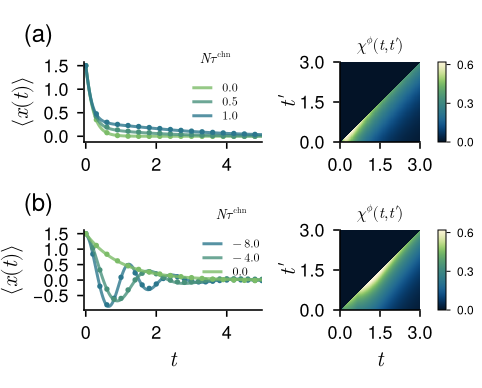

CairoMakie.Screen{IMAGE}


In [ ]:
# Run TransientDMFTVSSimulation.jl 
data = load(joinpath("results", "TransientDMFTVSSimulation.jld2"))

N = data["N"]
positive_results = data["positive_results"]
negative_results = data["negative_results"]
dt_vec_positive = data["dt_vec_positive"]
dt_vec_negative = data["dt_vec_negative"] 

n_colors = max(length(positive_results), length(negative_results))
colors = reverse(cgrad(:navia, 2n_colors + 6, categorical=true))[4:2:(2n_colors + 2)]

function dmft_time_grid(dmft, dmft_dt)
    if :times in propertynames(dmft) && length(dmft.times) == length(dmft.mx)
        return dmft.times
    end
    return range(0.0; step=dmft_dt, length=length(dmft.mx))
end

function plot_transient_results!(ax, results, dt_vec, colors; sim_stride=2)
    sim_strides = sim_stride isa Integer ? fill(sim_stride, length(results)) : sim_stride
    for (i, (result, dmft_dt)) in enumerate(zip(results, dt_vec))
        color = colors[i]
        dmft = result.DMFTResult
        sim = result.SimulationResult
        dmft_times = dmft_time_grid(dmft, dmft_dt)
        sim_idx = 1:sim_strides[i]:length(sim.times)
        label = L"%$(round(N * result.τchn, digits=1))"

        lines!(ax, dmft_times, dmft.mx;
            color=color, linewidth=1.5, alpha=0.8, label=label)
        errorbars!(ax, sim.times[sim_idx], sim.mx_mean[sim_idx],
            sim.mx_std[sim_idx], sim.mx_std[sim_idx];
            color=color, linewidth=0.8, alpha=0.8)
        scatter!(ax, sim.times[sim_idx], sim.mx_mean[sim_idx];
            color=color, markersize=3.8, marker=:circle)
    end
end

function response_slice(result, dmft_dt; tmax=3.0)
    dmft = result.DMFTResult
    times = dmft_time_grid(dmft, dmft_dt)
    idx = findall(t -> t <= tmax, times)
    return times[idx], dmft.χϕ[idx, idx]
end

positive_response_idx = argmax(abs.([result.τchn for result in positive_results]))
negative_response_idx = argmax(abs.([result.τchn for result in negative_results]))
positive_response_times, positive_response = response_slice(
    positive_results[positive_response_idx], dt_vec_positive[positive_response_idx])
negative_response_times, negative_response = response_slice(
    negative_results[negative_response_idx], dt_vec_negative[negative_response_idx])
response_colorrange = (0.0, 0.62)
response_colormap = :navia

fig = Figure(size=(3.35*72, 2.7*72), figure_padding=(1f0, 3f0, 2f0, 2f0))
ax_pos = Axis(fig[1, 1:2];
    ylabel=L"\langle x(t) \rangle", limits=(-0.05, 5.0, nothing, nothing))
ax_neg = Axis(fig[2, 1:2];
    xlabel=L"t", limits=(-0.05, 5.0, nothing, nothing),
    ylabel=L"\langle x(t) \rangle")
ax_pos_response = Axis(fig[1, 3];
    title=L"\chi^\phi(t,t')", titlesize=8,
    ylabel=L"t'", ylabelpadding=0,
    aspect=1, xticks=0:1.5:3, yticks=0:1.5:3,
    limits=(0.0, 3.0, 0.0, 3.0))
ax_neg_response = Axis(fig[2, 3];
    title=L"\chi^\phi(t,t')", titlesize=8,
    xlabel=L"t", ylabel=L"t'", ylabelpadding=0,
    aspect=1, xticks=0:1.5:3, yticks=0:1.5:3,
    limits=(0.0, 3.0, 0.0, 3.0))

negative_sim_strides = [iszero(result.τchn) ? 3 : 2 for result in negative_results]
plot_transient_results!(ax_pos, positive_results, dt_vec_positive, colors; sim_stride=3)
plot_transient_results!(ax_neg, negative_results, dt_vec_negative, reverse(colors); sim_stride=negative_sim_strides)
hm_pos = heatmap!(ax_pos_response, positive_response_times, positive_response_times, positive_response;
    colormap=response_colormap,
    colorrange=response_colorrange,
    rasterize=10)
hm_neg = heatmap!(ax_neg_response, negative_response_times, negative_response_times, negative_response;
    colormap=response_colormap,
    colorrange=response_colorrange,
    rasterize=10)
Colorbar(fig[1, 4], hm_pos; width=4, height=40, ticks=[0.0, 0.3, 0.6],
    ticksize=2, tickwidth=0.5, spinewidth=0.5, ticklabelsize=6)
Colorbar(fig[2, 4], hm_neg; width=4, height=40, ticks=[0.0, 0.3, 0.6],
    ticksize=2, tickwidth=0.5, spinewidth=0.5, ticklabelsize=6)

axislegend(ax_pos, L"N\tau^{\mathrm{chn}}";
    titlesize=7, patchsize=(10, 6), position=(1.0, 0.1), labelsize=6, rowgap=1)
axislegend(ax_neg, L"N\tau^{\mathrm{chn}}";
    titlesize=7, patchsize=(10, 6), position=(1.3, -0.2), labelsize=6, rowgap=1)

Label(fig[1, 1:2, TopLeft()], "(a)"; fontsize=12, padding=(0f0, 5f0, 7f0, 0f0))
Label(fig[2, 1:2, TopLeft()], "(b)"; fontsize=12, padding=(0f0, 5f0, 7f0, 0f0))
linkxaxes!(ax_pos, ax_neg)
colgap!(fig.layout, 6)
colsize!(fig.layout, 4, Fixed(8))
rowgap!(fig.layout, 8)
# save("images/TransientDynamics.pdf", fig, pt_per_unit=1)
display(fig)